In [1]:
import sys
import os
from pathlib import Path

if 'google.colab' in sys.modules:
    !pip install -U ipython
    !git clone https://github.com/AdrianPanasiewicz/QML_for_radar_classification.git
    repo_path = '/content/QML_for_radar_classification'
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

    colab_run_dir = os.path.join(repo_path, 'colab_run')
    os.makedirs(colab_run_dir, exist_ok=True)
    os.chdir(colab_run_dir)

    !pip install -q pennylane
    !pip install "ray[tune]"


%load_ext autoreload
%autoreload 2

%aimport -torch
%aimport -numpy
%aimport -qiskit
%aimport -pennylane
%aimport -ray
%aimport -sklearn

# These import from Data folder are necessary for pickle load to work
from Data.Primitives.environment_classes import Drone, Radar, Context
from Data.Primitives.noise_models import AdditiveWhiteGaussianNoise
from Data.Primitives.presets import *
from Data.Generators.synthetic_dataset_generator import DatasetMetadata, DataRequest

from MachineLearning.Processing.file_loader import SyntheticDataFileLoader
from MachineLearning.Processing.frequency_domain_parser import FrequencyDomainDataParser
from MachineLearning.Processing.time_domain_parser import TimeDomainDataParser
from MachineLearning.Torch_datasets.synthetic_time_dataset import SyntheticTimeDomainRadarDataset
from MachineLearning.Torch_datasets.synthetic_frequency_dataset import SyntheticFrequencyDomainRadarDataset
from MachineLearning.Models.experiment_pure.classical_neural_network import ClassicalNeuralNetwork
from MachineLearning.Models.experiment_pure.quantum_neural_network import QuantumNeuralNetwork
from MachineLearning.Processing.data_visualizer import DataVisualizer
from MachineLearning.Trainers.statistical_trainer import TrainerForModelStatistics
from MachineLearning.Trainers.hyperparameter_trainer import TrainerForHyperparameterSearch

from matplotlib import pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import sympy

import torch
from torch import nn
from torch.nn.functional import normalize
from torch.utils.data import DataLoader
from torch.optim import SGD

import ray
from ray import tune
from ray.tune import Checkpoint
from ray.tune.schedulers import ASHAScheduler

MODEL_REGISTRY = {
    "ClassicalNeuralNetwork": ClassicalNeuralNetwork,
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.7/625.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 10.1 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.12.0 which is incompatible.
movie

Cloning into 'QML_for_radar_classification'...
remote: Enumerating objects: 194, done.
remote: Counting objects: 100% (194/194), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 194 (delta 85), reused 154 (delta 48), pack-reused 0 (from 0)
Receiving objects: 100% (194/194), 28.78 MiB | 35.33 MiB/s, done.
Resolving deltas: 100% (85/85), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 77.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 136.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.5 MB/s e

### Checking preprocessing functionalities

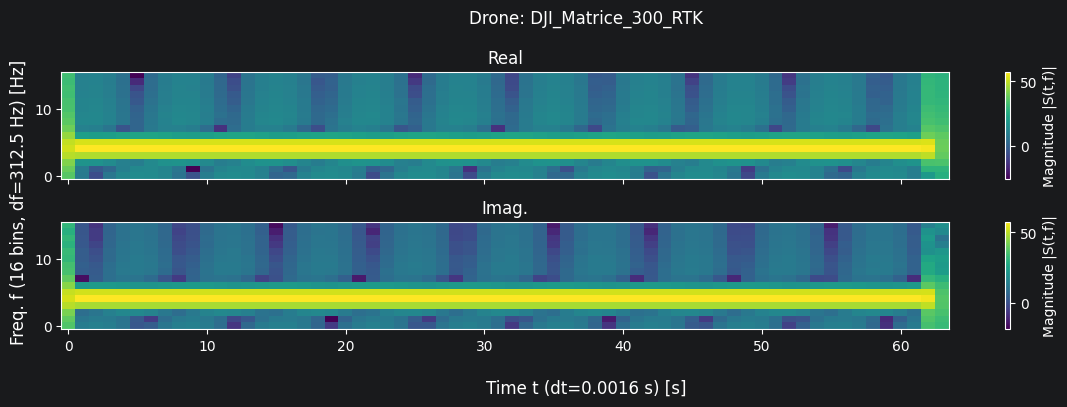

In [9]:
PROJECT_ROOT = Path().cwd().parent
type = "time_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = TimeDomainDataParser()
signal, label, misc_data = td_data_parser.extract_training_data_and_label(obj)
td_data_parser.plot_drone_spectrogram(signal, misc_data, nperseg=32, noverlap=16)

In [10]:
parsed_signal, label, misc_data = td_data_parser.parse_data_object(obj)
parsed_signal, label, misc_data

(tensor([ 7.0232,  3.6288,  2.5064,  2.2650,  1.9713,  2.2520,  2.4046,  3.3200,
          6.2894, 89.2546]),
 1,
 DataRequest(request_name='label=DJI_Matrice_300_RTK', drone=Drone(name='DJI_Matrice_300_RTK', N=2, L_1=0.05, L_2=0.2665, f_rot=70), radar=Radar(λ=0.02998, f_c=9999748432.288193), context=Context(R=1520.0568606927932, V_rad=29.999718426099054, θ=0.3926806281264518, Φ_p=0.6228512920884408, A_r=7.299403777764336, snr=np.int64(25), t_start=0, t_stop=0.1, dt=0.0001), noise_model=<Data.noise_models.AdditiveWhiteGaussianNoise object at 0x000001B200591040>, sample_size=70))

In [11]:
PROJECT_ROOT = Path().cwd().parent
type = "frequency_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = FrequencyDomainDataParser()
signal, label, misc_data = td_data_parser.parse_data_object(obj, bin_size=1, return_mag=False)
print(signal.shape)

torch.Size([2, 16, 64])


### Hyperparameter learner

In [2]:
# Safely import the colab module
try:
    from google.colab import output
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = Path().cwd().parent
ray.shutdown()

ctx = ray.init(
    _metrics_export_port=8080,
    runtime_env={
        "working_dir": str(PROJECT_ROOT),
        "excludes": [
            "Data/Datasets"
        ]
    }
)

if IN_COLAB:
    print("Loading Ray Dashboard:")
    output.serve_kernel_port_as_iframe(8265, height=600)

    print("Loading Ray Metrics Export:")
    output.serve_kernel_port_as_iframe(8080, height=400)
else:
    print(f"Running locally. Dashboard available at: {ctx.dashboard_url}")
    print("Metrics available at: http://127.0.0.1:8080")

2026-04-21 08:53:54,511	INFO worker.py:2012 -- Started a local Ray instance.
2026-04-21 08:53:54,516	WARNING working_dir.py:86 -- Directory '.git' is now ignored by default when packaging the working directory. To disable this behavior, set the `RAY_OVERRIDE_RUNTIME_ENV_DEFAULT_EXCLUDES=''` environment variable.
2026-04-21 08:53:54,529	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/content/QML_for_radar_classification/.idea/.gitignore')]
2026-04-21 08:53:54,535	INFO packaging.py:691 -- Creating a file package for local module '/content/QML_for_radar_classification'.
2026-04-21 08:53:54,549	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/content/QML_for_radar_classification/.idea/.gitignore')]
2026-04-21 08:53:54,554	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_91245f8ebe6011f0.zip' (0.61MiB) to Ray cluster...
2026-04-21 08:53:54,558	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray

Loading Ray Dashboard:


/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


<IPython.core.display.Javascript object>

Loading Ray Metrics Export:


<IPython.core.display.Javascript object>

In [3]:
config_params = 128
divs_array = sympy.divisors(config_params)

pair_map = {div : config_params // div for div in divs_array}

config = {
    "layers": tune.grid_search(list(pair_map.keys())),
    "neurons_per_layer": tune.sample_from(lambda config: pair_map[config["layers"]]),
    "lr": tune.loguniform(1e-6, 1e-1),
    "batch_size": tune.choice([2, 4, 8, 16]),
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    'epochs' : 250
}


max_num_epochs = 500
num_trials =  100
scheduler = ASHAScheduler(
    max_t=max_num_epochs,
    grace_period=1,
    reduction_factor=2,
)

cpus_per_trial = 2
gpus_per_trial = 1

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = TrainerForHyperparameterSearch(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=testing_path,
    criterion = nn.CrossEntropyLoss()
)

tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(trainer.train_model, model_class=ClassicalNeuralNetwork),
        resources={"cpu": cpus_per_trial, "gpu": gpus_per_trial}
    ),
    tune_config=tune.TuneConfig(
        metric="loss",
        mode="min",
        scheduler=scheduler,
        num_samples=num_trials,
        trial_dirname_creator=lambda trial: f"t_{trial.trial_id}"
    ),
    param_space=config,
)
results = tuner.fit()

+--------------------------------------------------------------------+
| Configuration for experiment     train_model_2026-04-21_08-53-58   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        AsyncHyperBandScheduler           |
| Number of trials                 800                               |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_model_2026-04-21_08-53-58
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-04-21_08-53-44_191653_455/artifacts/2026-04-21_08-53-59/train_model_2026-04-21_08-53-58/driver_artifacts`

Trial status: 200 PENDING
Current time: 2026-04-21 08:54:59. Total running time: 59s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
+-------------------------------------------------------------

(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00000/checkpoint_000000)
(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00000/checkpoint_000001)
(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00000/checkpoint_000002)
(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00000/checkpoint_000003)
(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00000/checkpoint_000004)
(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_mod


Trial status: 1 RUNNING | 200 PENDING
Current time: 2026-04-21 08:55:29. Total running time: 1min 29s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Current best trial: a2f82_00000 with loss=0.6933624744415283 and params={'layers': 1, 'neurons_per_layer': 128, 'lr': 1.449204463340136e-05, 'batch_size': 16, 'device': 'cuda', 'epochs': 250}
+--------------------------------------------------------------------------------------------------------------------------------+
| Trial name                status              lr     batch_size     layers     iter     total time (s)       loss     accuracy |
+--------------------------------------------------------------------------------------------------------------------------------+
| train_model_a2f82_00000   RUNNING    1.4492e-05              16          1      133            18.1154   0.693362          0.5 |
| train_model_a2f82_00001   PENDING    0.0174811                8          2                            

(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00000/checkpoint_000133)
(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00000/checkpoint_000134)
(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00000/checkpoint_000135)
(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00000/checkpoint_000136)
(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00000/checkpoint_000137)
(train_model pid=1438) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_mod


Trial train_model_a2f82_00000 errored after 250 iterations at 2026-04-21 08:55:43. Total running time: 1min 43s
Error file: /tmp/ray/session_2026-04-21_08-53-44_191653_455/artifacts/2026-04-21_08-53-59/train_model_2026-04-21_08-53-58/driver_artifacts/t_a2f82_00000/error.txt
+-------------------------------------------------------------+
| Trial train_model_a2f82_00000 result                        |
+-------------------------------------------------------------+
| checkpoint_dir_name                       checkpoint_000249 |
| time_this_iter_s                                     0.1015 |
| time_total_s                                       31.32404 |
| training_iteration                                      250 |
| accuracy                                            0.48929 |
| loss                                     0.6930314898490906 |
+-------------------------------------------------------------+

Trial train_model_a2f82_00001 started with configuration:
+------------------------

...


Trial train_model_a2f82_00005 started with configuration:
+--------------------------------------------------+
| Trial train_model_a2f82_00005 config             |
+--------------------------------------------------+
| batch_size                                     2 |
| device                                      cuda |
| epochs                                       250 |
| layers                                        32 |
| lr                                       0.00204 |
| neurons_per_layer                              4 |
+--------------------------------------------------+


(train_model pid=2307) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00005/checkpoint_000000)
(train_model pid=2307) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00005/checkpoint_000001)
(train_model pid=2307) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00005/checkpoint_000002)
2026-04-21 08:57:53,706	WARNING tune.py:219 -- Stop signal received (e.g. via SIGINT/Ctrl+C), ending Ray Tune run. This will try to checkpoint the experiment state one last time. Press CTRL+C (or send SIGINT/SIGKILL/SIGTERM) to skip. 
2026-04-21 08:57:53,739	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_model_2026-04-21_08-53-58' in 0.0319s.



Trial status: 2 ERROR | 3 TERMINATED | 1 RUNNING | 200 PENDING
Current time: 2026-04-21 08:57:53. Total running time: 3min 54s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Current best trial: a2f82_00001 with loss=0.5908969640731812 and params={'layers': 2, 'neurons_per_layer': 64, 'lr': 0.017481135759290067, 'batch_size': 8, 'device': 'cuda', 'epochs': 250}
+----------------------------------------------------------------------------------------------------------------------------------+
| Trial name                status                lr     batch_size     layers     iter     total time (s)       loss     accuracy |
+----------------------------------------------------------------------------------------------------------------------------------+
| train_model_a2f82_00005   RUNNING      0.0020382                2         32        3           12.3427    0.696099     0.5      |
| train_model_a2f82_00002   TERMINATED   0.00334666               8       

KeyboardInterrupt: 

(train_model pid=2307) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_model_2026-04-21_08-53-58/t_a2f82_00005/checkpoint_000003)


### Statistical learner

In [2]:
def l1_normalize_1d(x):
    return normalize(x, p=1, dim=0)

def l2_normalize_1d(x):
    return normalize(x, dim=0)

In [ ]:
PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"


config = {
    "layers": 2,
    "neurons_per_layer": 250,
    "lr": 1e-3,
    "batch_size": 16,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    'epochs' : 100
}

trainer = TrainerForModelStatistics(training_path, validating_path, testing_path, criterion = nn.CrossEntropyLoss())
data_array_all_runs = trainer.train_model(ClassicalNeuralNetwork, config, number_of_trials=10, number_of_epochs=500)

Model runs:  20%|██        | 2/10 [01:53<07:32, 56.51s/it]

In [ ]:
data_array = torch.tensor(
    [data_array_all_runs[i]['accuracy'] for i in range(len(data_array_all_runs))],
    dtype=torch.float32
)

plotter = DataVisualizer()
means, stds = plotter.calculate_statistics(data_array)
plotter.plot_statistics(means, stds)

### Quantum Neural Network

In [13]:
batch_size = 64
num_qubits = 10

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"

training_data = SyntheticTimeDomainRadarDataset(training_path)
validating_data = SyntheticTimeDomainRadarDataset(validating_path, mean=training_data.mean, std=training_data.std)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
validating_dataloader = DataLoader(validating_data, batch_size=64, shuffle=True)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
quantum_model = QuantumNeuralNetwork(num_qubits).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(quantum_model.parameters(), lr=1e-3)

trainer = TrainerForHyperparameterSearch(
    training_dataloader=train_dataloader,
    validating_dataloader=validating_dataloader,
    testing_dataloader=None,
    loss_fn=criterion,
)

epochs = 10
accuracy_array=[]
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    trainer.train()
    acc = trainer.test()
    accuracy_array.append(acc)
print("Done!")

Epoch 1
-------------------------------
loss: 1.802852  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795701 

Epoch 2
-------------------------------
loss: 1.784019  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795918 

Epoch 3
-------------------------------
loss: 1.789067  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795346 

Epoch 4
-------------------------------
loss: 1.792531  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795292 

Epoch 5
-------------------------------
loss: 1.789393  [   64/ 4620]


KeyboardInterrupt: 